# Sparse Representation

"Sparsification" takes much too long!

**BUT:** Might be useful when doing multiple impact calculations that cannot be predicted?

In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import pandas as pd
import xarray as xr

# Single exposure array with time axis
exposure = xr.concat(
    [
        xr.load_dataarray(
            "data/exposure/deu_ppp_2000_1km_Aggregated_UNadj.tif",
            decode_coords="all",
            engine="rasterio",
        ),
        xr.load_dataarray(
            "data/exposure/deu_ppp_2001_1km_Aggregated_UNadj.tif",
            decode_coords="all",
            engine="rasterio",
        ),
    ],
    dim=pd.DatetimeIndex(["2021-06-12", "2021-06-15"], name="time"),
)
exposure = exposure.squeeze()
# exposure = exposure.coarsen(x=5, y=5, boundary="trim").sum()
# exposure = exposure.rename({"x": "longitude", "y": "latitude"})
exposure

<xarray.DataArray 'band_data' (time: 2, y: 934, x: 1100)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 16B 2021-06-12 2021-06-15
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  3301.6967773438
    STATISTICS_MEAN:     122.93104760496
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   266.87357580513

In [2]:
import climadace

exposure = climadace.to_sparse(exposure)
exposure

Format,gcxs
Data Type,float32
Shape,"(2, 934, 1100)"
nnz,2047148
Density,0.9962760365972357
Read-only,True
Size,23.4M
Storage ratio,2.99
Compressed Axes,"(0,)"


In [15]:
from dask.base import visualize

delayed = climadace.to_dense(exposure, chunks="1MiB").to_zarr(
    "data/output/flood.zarr", mode="w", compute=False
)
visualize(delayed, filename="sparse", format="pdf", optimize_graph=False)
delayed.compute()

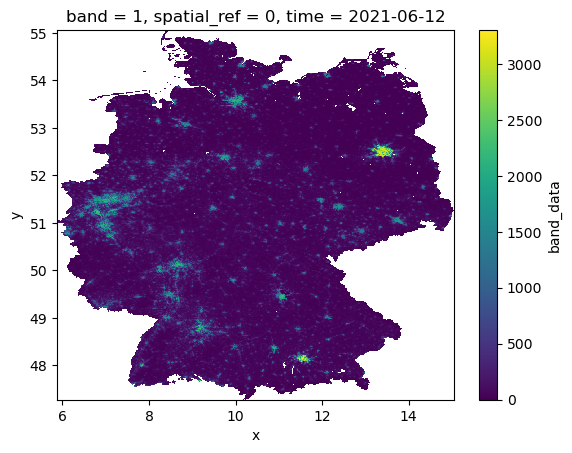

In [5]:
exposure.isel(time=0).plot()

In [6]:
from functools import partial
import numpy as np


def impact_func(intensity, threshold, half_point, exponent, scale):
    luk = (intensity - threshold) / (half_point - threshold)
    # luk = np.where(luk < 0, 0, luk)
    return np.maximum(scale * luk**exponent / (1 + luk**exponent), 0.0)


impf = partial(impact_func, threshold=0.1, half_point=1.0, scale=1.0, exponent=3)
impf = lambda intensity: impact_func(
    intensity, threshold=0.1, half_point=1.0, scale=1.0, exponent=3
)

In [7]:
import odc.geo.xr
import sparse

hazard = xr.open_dataset(
    "data/hazard/flood-2021-06-fine.nc", chunks="auto", decode_coords="all"
)["flood_depth"]
hazard = hazard.odc.assign_crs("EPSG:4326")
hazard = hazard.sel(time=exposure["time"])

# hazard = xr.DataArray(
#     data=hazard.data.map_blocks(lambda x: sparse.COO(x, fill_value=np.nan)),
#     coords=hazard.coords,
#     attrs=hazard.attrs,
# )
# hazard.data.dtype
hazard

<xarray.DataArray 'flood_depth' (latitude: 1859, longitude: 2183, number: 10,
                                 time: 2, step: 5)> Size: 2GB
dask.array<getitem, shape=(1859, 2183, 10, 2, 5), dtype=float32, chunksize=(620, 728, 4, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * number       (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time         (time) datetime64[ns] 16B 2021-06-12 2021-06-15
  * step         (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
    surface      float64 8B ...
    valid_time   (time, step) datetime64[ns] 80B dask.array<chunksize=(2, 5), meta=np.ndarray>
  * longitude    (longitude) float64 17kB 5.878 5.883 5.887 ... 14.97 14.97
  * latitude     (latitude) float64 15kB 55.02 55.02 55.01 ... 47.29 47.28 47.28
    spatial_ref  int32 4B 4326
    band         int64 8B 1

In [ ]:
import climadace

hazard = climadace.reproject_hazard(
    hazard, exposure, resampling="nearest", cache_result=True
)
hazard = climadace.to_sparse(hazard).compute()
hazard

NOT CACHING!


Format,gcxs
Data Type,float32
Shape,"(934, 1100, 10, 2, 5)"
nnz,395000
Density,0.003844656414249562
Read-only,True
Size,4.5M
Storage ratio,0.01
Compressed Axes,"(0,)"


In [ ]:
import climadace
import numpy as np
import sparse

hazard = climadace.reproject_hazard(
    hazard, exposure, resampling="nearest", cache_result=True
)
hazard = climadace.cache_zarr(hazard, climadace.DATA_DIR / "output" / "hazard")
hazard = xr.apply_ufunc(
    lambda x: sparse.GCXS.from_numpy(np.where(np.isnan(x), 0.0, x), fill_value=0.0),
    hazard,
    # dask="parallelized",
    output_dtypes=[np.float32],
).compute()
hazard

/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/dask/array/core.py:4988: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(


NOT CACHING!


Format,gcxs
Data Type,float32
Shape,"(9345, 10999, 10, 2, 5)"
nnz,52632912
Density,0.00512064762344512
Read-only,True
Size,602.4M
Storage ratio,0.02
Compressed Axes,"(0,)"


In [ ]:
import climadace
import numpy as np
import sparse
from dask.distributed import Client

with Client(n_workers=2, threads_per_worker=2, memory_limit="4GB"):
    hazard = xr.open_dataarray(
        climadace.DATA_DIR / "output" / "hazard.zarr",
        chunks="auto",
        decode_coords="all",
    )
    hazard = xr.apply_ufunc(
        lambda x: sparse.GCXS.from_numpy(np.where(np.isnan(x), 0.0, x), fill_value=0.0),
        hazard,
        dask="parallelized",
        output_dtypes=[np.float32],
    ).compute()
hazard

/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


Format,gcxs
Data Type,float32
Shape,"(9345, 10999, 10, 2, 5)"
nnz,52632912
Density,0.00512064762344512
Read-only,True
Size,602.4M
Storage ratio,0.02
Compressed Axes,"(0,)"


In [10]:
impact = impf(hazard) * exposure
# impact = hazard
# impact = impact.compute()
impact

Format,gcxs
Data Type,float32
Shape,"(934, 1100, 10, 2, 5)"
nnz,196800
Density,0.001915514891960288
Read-only,True
Size,2.3M
Storage ratio,0.01
Compressed Axes,"(3,)"


In [11]:
climadace.to_dense(impact).to_zarr("data/output/flood.zarr", mode="w")

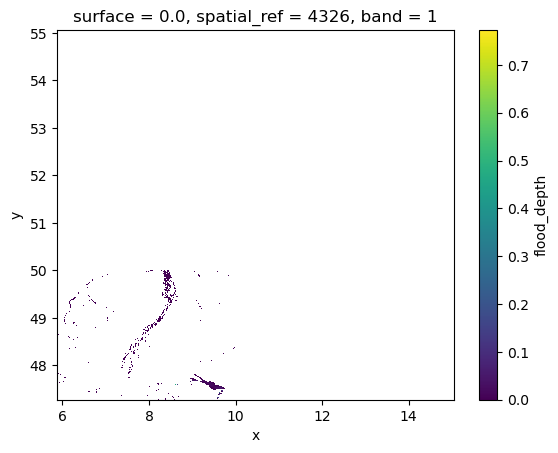

In [12]:
hazard.max(dim=["step", "time", "number"]).plot()

In [ ]:
from dask.distributed import Client
import xarray as xr
import sparse


# hazard = xr.open_dataset(
#     "data/hazard/flood-2021-06-fine.nc", chunks="auto", decode_coords="all"
# )["flood_depth"]
# hazard = hazard.odc.assign_crs("EPSG:4326")
# hazard = hazard.sel(time=exposure["time"])
# hazard = xr.DataArray(
#     data=hazard.data.map_blocks(lambda x: sparse.COO(x, fill_value=np.nan)),
#     coords=hazard.coords,
#     attrs=hazard.attrs,
# )
# name = hazard.name

# with Client(n_workers=1, threads_per_worker=4, memory_limit="4GB"):

# exposure = xr.apply_ufunc(
#     lambda x: sparse.GCXS.from_numpy(np.where(np.isnan(x), 0.0, x), fill_value=0.0),
#     exposure,
#     dask="parallelized",
#     output_dtypes=["float"],
# )
# print(hazard)
# hazard = impf(hazard)

impact = impf(hazard) * exposure
# impact = hazard
impact = climadace.norm_chunks(impact)
impact = xr.apply_ufunc(
    lambda x: x.todense(),
    impact,
    dask="parallelized",
    output_dtypes=[np.float32],
)
# impact = xr.map_blocks(
#     lambda x: xr.Dataset(
#         {name: x[name].data.todense()}, coords=impact.coords, attrs=impact.attrs
#     ),
#     impact,
#     template=impact,
# )
impact.to_zarr("data/output/flood.zarr", mode="w")

impact